# UTCP LSTM Congestion Predictor


## Section 0 — Setup

In [1]:
%pip install tensorflow pandas numpy scikit-learn matplotlib --quiet

# Colab / local detection
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUNS_DIR       = '/content/drive/MyDrive/udp/runs'
    CACHE_DIR      = '/content/drive/MyDrive/udp/run_cache_v6'   # v6: rtt_us feature + SEQ_LEN=600
    MODEL_SAVE_DIR = '/content/drive/MyDrive/udp/models'
    IN_COLAB = True
except ImportError:
    RUNS_DIR       = '../log/runs'
    CACHE_DIR      = '../log/runs_cache_v6'   # v6: rtt_us feature + SEQ_LEN=600
    MODEL_SAVE_DIR = '.'
    IN_COLAB = False

print(f'Running in {"Colab" if IN_COLAB else "local"} mode')
print(f'RUNS_DIR  = {RUNS_DIR}')
print(f'CACHE_DIR = {CACHE_DIR}')

Mounted at /content/drive
Running in Colab mode
RUNS_DIR  = /content/drive/MyDrive/udp/runs
CACHE_DIR = /content/drive/MyDrive/udp/run_cache_v5


In [2]:
import os, random, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix, f1_score
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# A100: BF16 mixed precision — compute in bfloat16 on Tensor Cores,
# accumulate weights in float32. More numerically stable than float16.
tf.keras.mixed_precision.set_global_policy('mixed_bfloat16')

print(f'TensorFlow {tf.__version__}')
print(f'Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}')

TensorFlow 2.19.0
Mixed precision policy: mixed_bfloat16


## Section 1 — Configuration

In [3]:
# ── Model selector ────────────────────────────────────────────────────────────
MODEL_TYPE    = 'stateful_lstm'   # 'patchtst' | 'stateful_lstm'

# ── Time binning ──────────────────────────────────────────────────────────────
BIN_SIZE_MS      = 5
N_MIN_BINS       = 10
N_PRE_ONSET_RTTS = 2

# ── Sequence config ───────────────────────────────────────────────────────────
SEQ_LEN     = 600   # PatchTST window length (bins)
STRIDE      = 3     # PatchTST sliding-window step
N_FEATURES  = 8

# ── PatchTST architecture ─────────────────────────────────────────────────────
PATCH_LEN    = 16
PATCH_STRIDE = 8
D_MODEL      = 128
N_HEADS      = 8
N_LAYERS     = 3
FFN_DIM      = 256
DROPOUT_TR   = 0.1
DROPOUT_CLS  = 0.2

# ── Stateful LSTM architecture ────────────────────────────────────────────────
LSTM_UNITS   = [512, 512, 256]  # cuDNN-compatible: no recurrent_dropout
LSTM_DROPOUT = 0.2              # input dropout only
TBPTT_LEN    = 300              # bins per training chunk  (300 × 5 ms = 1.5 s)
TBPTT_BATCH  = 64               # chunks per gradient step on A100

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 2048   # PatchTST only
EPOCHS      = 50
PATIENCE    = 8
LR          = 1e-3

# ── Data split ────────────────────────────────────────────────────────────────
TRAIN_FRAC  = 0.60
VAL_FRAC    = 0.20
RANDOM_SEED = 42

# ── Dynamic paths ─────────────────────────────────────────────────────────────
MODEL_SAVE = f'utcp_{MODEL_TYPE}_v6.keras'
META_SAVE  = f'utcp_{MODEL_TYPE}_v6_meta.json'
CACHE_DIR  = os.path.join(CACHE_DIR, MODEL_TYPE)   # partition cache per model type

meta_path  = os.path.join(MODEL_SAVE_DIR, META_SAVE)
model_path = os.path.join(MODEL_SAVE_DIR, MODEL_SAVE)
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Features ──────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'rtt_us',         # raw per-bin mean RTT  — most direct congestion signal
    'srtt_us',        # smoothed RTT
    'rttvar_us',      # RTT variance
    'queue_delay_us', # rtt - min_rtt
    'rtt_delta_us',   # d(RTT)/dt
    'rtt_accel_us',   # d²(RTT)/dt²
    't_dupacks',      # dup-ACK count
    'utilization',    # flight/window
]

RAW_COLS = [
    'zlog_ts',
    'timestamp_us', 'rtt_us', 'srtt_us', 'rttvar_us', 'rto_us', 'min_rtt_us',
    'queue_delay_us', 'rtt_delta_us', 'rtt_accel_us', 'rto_delta_us',
    'cwnd', 'ssthresh', 'snd_wnd', 'flight_size', 'newly_acked',
    'inter_ack_us',
    'ca_state', 't_dupacks', 't_rxtshift', 'is_dup_ack', 'is_timeout',
]

print(f'Config loaded  model={MODEL_TYPE}')


Config loaded.


## Section 2 — Data Loading & Binning

In [4]:
def load_and_bin_run(path: str) -> tuple[pd.DataFrame, float] | None:
    """
    Load one lstm_output.csv, derive features, normalize per-connection,
    and resample into BIN_SIZE_MS time bins.

    Returns (binned_df, run_min_rtt_us) or None if the run is too short /
    malformed.  run_min_rtt_us is the raw median min-RTT (µs) used for
    per-connection normalization — callers need it to reconstruct physical
    time in label_pre_onset_only().
    """
    try:
        df = pd.read_csv(
            path, names=RAW_COLS, header=None,
            on_bad_lines='skip', low_memory=False
        )
        df = df.apply(pd.to_numeric, errors='coerce')
        df.drop(columns=['zlog_ts'], inplace=True)
        df.dropna(subset=['timestamp_us', 'min_rtt_us', 'srtt_us'], inplace=True)
        df = df[df['min_rtt_us'] > 0].reset_index(drop=True)

        if len(df) < 10:
            return None

        # ── Derived feature: utilization ──────────────────────────────────────
        eff_win = df[['cwnd', 'snd_wnd']].min(axis=1).clip(lower=1)
        df['utilization'] = (df['flight_size'] / eff_win).clip(0.0, 2.0)

        # ── Per-connection RTT normalization (before binning) ─────────────────
        run_min_rtt = df['min_rtt_us'].replace(0, np.nan).median()
        if pd.isna(run_min_rtt) or run_min_rtt <= 0:
            run_min_rtt = 1.0

        for col in ['rtt_us', 'srtt_us', 'rttvar_us', 'queue_delay_us',
                    'rtt_delta_us', 'rtt_accel_us']:
            df[col] = df[col] / run_min_rtt

        # t_dupacks: normalize by fast-retransmit threshold (3)
        df['t_dupacks'] = df['t_dupacks'] / 3.0

        # ── Relative time axis ────────────────────────────────────────────────
        df['rel_time_ms'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1000.0

        # ── Bin into BIN_SIZE_MS windows ──────────────────────────────────────
        max_time = df['rel_time_ms'].max()
        bin_edges = np.arange(0, max_time + BIN_SIZE_MS, BIN_SIZE_MS)
        df['bin'] = pd.cut(df['rel_time_ms'], bins=bin_edges,
                           labels=False, right=False)
        df.dropna(subset=['bin'], inplace=True)
        df['bin'] = df['bin'].astype(int)

        agg = {
            'rtt_us':         'mean',   # raw RTT per bin — direct signal
            'srtt_us':        'mean',
            'rttvar_us':      'mean',
            'queue_delay_us': 'max',
            'rtt_delta_us':   'mean',
            'rtt_accel_us':   'mean',
            't_dupacks':      'max',
            'utilization':    'mean',
            # Label columns — NOT features, kept for labeling only
            'ca_state':       'max',
            'is_timeout':     'max',
            'cwnd':           'mean',
        }
        binned = df.groupby('bin').agg(agg)

        # Fill any empty bins (no ACKs in that window)
        all_bins = pd.RangeIndex(binned.index.min(), binned.index.max() + 1)
        binned = binned.reindex(all_bins)
        binned = binned.interpolate(method='linear').fillna(0)

        # Clip after normalization to suppress outlier spikes
        for col in FEATURE_COLS:
            binned[col] = binned[col].clip(-10.0, 10.0)

        # Sanity: log the raw min-RTT so callers can verify the scale is sane
        min_rtt_ms = run_min_rtt / 1000.0
        if min_rtt_ms < 0.1 or min_rtt_ms > 5000.0:
            print(f'  [WARN] {path}: unusual run_min_rtt={min_rtt_ms:.2f} ms')

        return binned, run_min_rtt   # raw µs baseline returned for labeling

    except Exception as e:
        print(f'  [SKIP] {path}: {e}')
        return None


print('load_and_bin_run() defined.')

load_and_bin_run() defined.


## Section 3 — Labeling

In [5]:
def label_pre_onset_only(binned: pd.DataFrame, run_min_rtt_us: float) -> np.ndarray:
    """
    Label ONLY the N_PRE_ONSET_RTTS-RTT window BEFORE each congestion episode
    first starts. Does NOT label during congestion itself.

    One positive region per episode onset — the model must fire while the
    connection is still in a clean state, not after degradation has begun.

    Congestion event = ca_state_max >= 3  OR  is_timeout_max >= 1

    run_min_rtt_us: raw per-connection baseline in microseconds (returned by
    load_and_bin_run).  Required to convert the normalized srtt back into
    real time so that n_bins reflects a true N_PRE_ONSET_RTTS-RTT window.
    """
    y = np.zeros(len(binned), dtype=np.float32)

    ca_arr   = binned['ca_state'].values
    to_arr   = binned['is_timeout'].values
    srtt_arr = binned['srtt_us'].values   # normalized: srtt / run_min_rtt (dimensionless)

    # Reconstruct raw SRTT in ms so we can compute a bin count with real units.
    # srtt_arr * run_min_rtt_us gives raw µs; divide by 1000 → ms.
    srtt_raw_ms = srtt_arr * run_min_rtt_us / 1000.0

    is_cong = (ca_arr >= 3) | (to_arr >= 1)

    in_cong = False
    for k in range(len(is_cong)):
        if is_cong[k] and not in_cong:
            # Use the bin just BEFORE the onset (k-1) to avoid sampling an
            # already-elevated SRTT at the moment congestion is declared.
            pre_k = max(0, k - 1)
            srtt_ms_pre = srtt_raw_ms[pre_k]

            # n_bins = how many BIN_SIZE_MS slots fit in N_PRE_ONSET_RTTS RTTs
            n_bins = max(N_MIN_BINS,
                         int((srtt_ms_pre / BIN_SIZE_MS) * N_PRE_ONSET_RTTS))
            start  = max(0, k - n_bins)
            y[start : k] = 1.0   # k excluded: no label during congestion
            in_cong = True
        elif not is_cong[k]:
            in_cong = False

    return y


print('label_pre_onset_only() defined.')


label_pre_onset_only() defined.


## Section 4 — Sanity Plots

In [6]:
# Find all available runs
csv_paths = sorted(glob.glob(os.path.join(RUNS_DIR, '*', 'lstm_output.csv')))
assert len(csv_paths) > 0, (
    f'No lstm_output.csv files found under {RUNS_DIR}.\n'
    'Run collect.sh to generate training data first.'
)
print(f'Found {len(csv_paths)} runs in {RUNS_DIR}')

Found 255 runs in /content/drive/MyDrive/udp/runs


In [7]:
# ── Prune runs with excessive consecutive timeouts ────────────────────────────
#MAX_CONSECUTIVE_TIMEOUTS = 10   # tune this threshold
#
#def count_max_consecutive_timeouts(path: str) -> int:
#    try:
#        df = pd.read_csv(path, names=RAW_COLS, header=None,
#                         on_bad_lines='skip', low_memory=False)
#        col = pd.to_numeric(df['is_timeout'], errors='coerce').fillna(0)  # ← name, not index
#        max_run = 0
#        cur_run = 0
#        for v in col:
#            if v >= 1:
#                cur_run += 1
#                max_run = max(max_run, cur_run)
#            else:
#                cur_run = 0
#        return max_run
#    except Exception as e:
#        print(f'  [SKIP] {path}: {e}')
#        return 0
#
#bad_paths = []
#for path in csv_paths:
#    n = count_max_consecutive_timeouts(path)
#    if n > MAX_CONSECUTIVE_TIMEOUTS:
#        bad_paths.append((path, n))
#
#print(f'Runs exceeding {MAX_CONSECUTIVE_TIMEOUTS} consecutive timeouts: {len(bad_paths)}')
#for path, n in sorted(bad_paths, key=lambda x: -x[1]):
#    print(f'  {n:4d}  {path}')

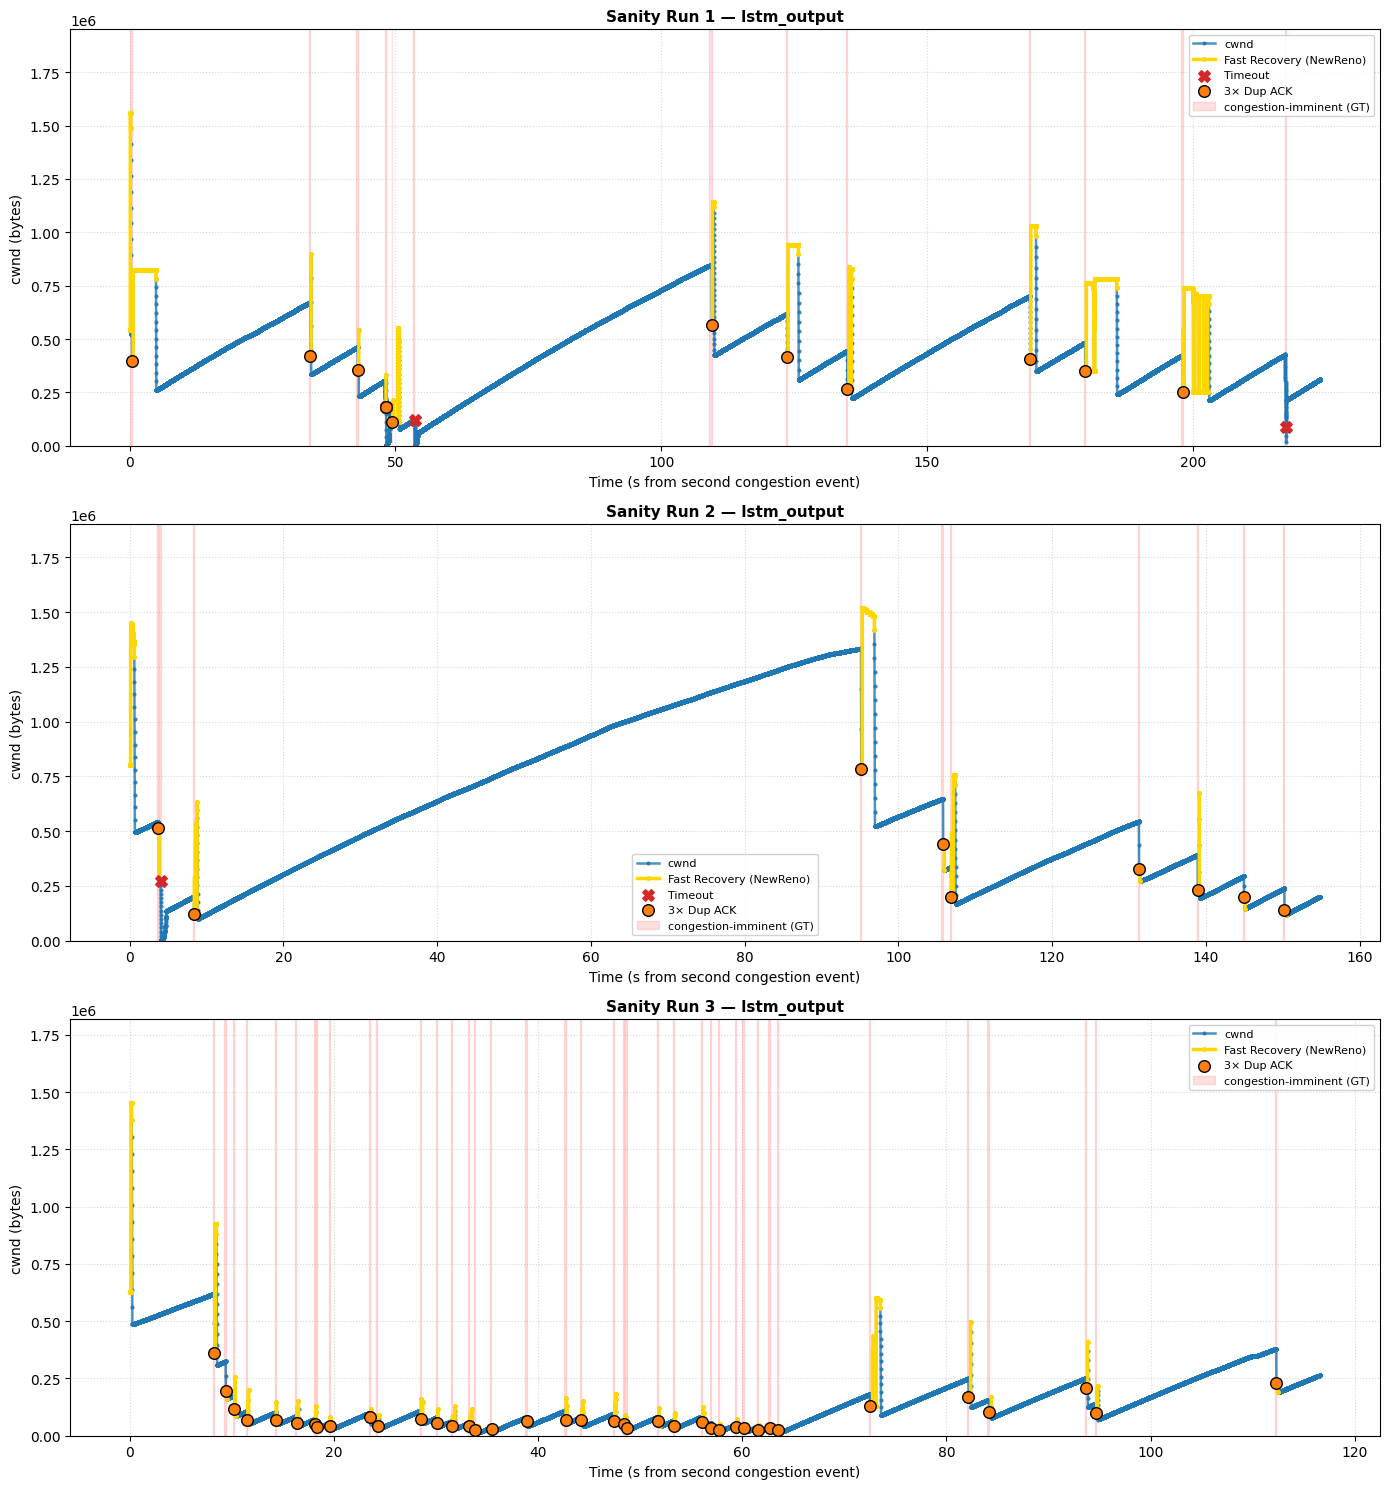

Sanity plots saved to sanity_v5.png


In [8]:
from pathlib import Path

# Plot 3 sample runs: cwnd + congestion event labels (NewReno-aware)
N_SANITY = min(3, len(csv_paths))
sample_paths = random.sample(csv_paths, N_SANITY)

fig, axes = plt.subplots(N_SANITY, 1, figsize=(14, 5 * N_SANITY))
if N_SANITY == 1:
    axes = [axes]

for row, path in enumerate(sample_paths):
    result = load_and_bin_run(path)
    if result is None:
        continue
    binned, run_min_rtt = result
    ax = axes[row]

    # ── Reconstruct a per-bin cwnd series ──────────────────────────────────
    SENTINEL = 0xFFFFFFFF
    cwnd = binned['cwnd'].replace(SENTINEL, np.nan).copy()

    # ── Skip the very first congestion event (initial CC convergence) ──────
    congestion_mask = (binned['ca_state'].values >= 3) | (binned['is_timeout'].values >= 1)
    congestion_bins = np.where(congestion_mask)[0]

    if len(congestion_bins) >= 2:
        start_bin = congestion_bins[1]
    elif len(congestion_bins) == 1:
        start_bin = congestion_bins[0]
    else:
        start_bin = 0

    cwnd   = cwnd.iloc[start_bin:].reset_index(drop=True)
    binned = binned.iloc[start_bin:].reset_index(drop=True)
    t = np.arange(len(cwnd)) * BIN_SIZE_MS / 1000.0

    # ── NewReno Fast Recovery flatlining ───────────────────────────────────
    cwnd_display = cwnd.copy()
    in_fr        = False
    fr_value     = None
    fr_segments  = []
    fr_start     = None

    for idx in range(len(binned)):
        ca  = binned['ca_state'].iloc[idx]
        dup = binned['t_dupacks'].iloc[idx] if 't_dupacks' in binned.columns else 0

        is_triple_dup = (ca == 3 and not in_fr)
        is_timeout    = binned['is_timeout'].iloc[idx] >= 1

        if is_triple_dup:
            in_fr    = True
            fr_value = cwnd_display.iloc[idx]
            fr_start = idx
        elif in_fr:
            is_partial_ack = (ca == 3 and dup > 0)
            if is_partial_ack:
                cwnd_display.iloc[idx] = fr_value
            elif ca < 3 or is_timeout:
                fr_segments.append((fr_start, idx))
                in_fr = False

    if in_fr and fr_start is not None:
        fr_segments.append((fr_start, len(cwnd_display) - 1))

    ax.plot(t, cwnd_display.values, color='#1f77b4', linewidth=1.8,
            marker='.', markersize=4, alpha=0.8, label='cwnd', zorder=2)

    for i, (s, e) in enumerate(fr_segments):
        seg_t    = t[s:e+1]
        seg_cwnd = cwnd_display.iloc[s:e+1].values
        ax.plot(seg_t, seg_cwnd, color='gold', linewidth=2.5,
                marker='.', markersize=5, alpha=1.0,
                label='Fast Recovery (NewReno)' if i == 0 else None, zorder=3)

    timeout_bins    = np.where(binned['is_timeout'].values >= 1)[0]
    triple_dup_bins = np.where(
        (binned['ca_state'].values == 3) &
        (np.concatenate([[False], binned['ca_state'].values[:-1] != 3]))
    )[0]

    if len(timeout_bins):
        ax.scatter(t[timeout_bins], cwnd_display.iloc[timeout_bins].values,
                   color='#d62728', marker='X', s=70, label='Timeout', zorder=5)

    if len(triple_dup_bins):
        ax.scatter(t[triple_dup_bins], cwnd_display.iloc[triple_dup_bins].values,
                   color='#ff7f0e', marker='o', s=70, edgecolors='black',
                   label='3× Dup ACK', zorder=5)

    y_label = label_pre_onset_only(binned, run_min_rtt)
    shade   = y_label.astype(bool)
    y_top   = cwnd_display.max() * 1.25 if not cwnd_display.isna().all() else 1
    ax.fill_between(t, 0, y_top, where=shade,
                    color='red', alpha=0.12, label='congestion-imminent (GT)', zorder=1)

    if not cwnd_display.dropna().empty:
        ax.set_ylim(0, y_top)

    ax.set_xlabel('Time (s from second congestion event)')
    ax.set_ylabel('cwnd (bytes)')
    ax.set_title(f'Sanity Run {row + 1} — {Path(path).stem}', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('sanity_v6.png', dpi=100)
plt.show()
print('Sanity plots saved to sanity_v6.png')

## Section 5 — Dataset Assembly & Train/Val/Test Split

In [ ]:
import multiprocessing, platform, gc

os.makedirs(CACHE_DIR, exist_ok=True)

def _assemble_one_run(path: str):
    """Load, bin, label, and package one run.
    PatchTST  → (n_windows, SEQ_LEN, N_FEATURES) + (n_windows,) labels.
    LSTM      → (n_chunks, TBPTT_LEN, N_FEATURES) + (n_chunks, TBPTT_LEN) labels.
    Returns (path, X_run, y_run) or None on failure / run too short.
    """
    run_id  = os.path.basename(os.path.dirname(path))
    cache_X = os.path.join(CACHE_DIR, f'{run_id}_X.npy')
    cache_y = os.path.join(CACHE_DIR, f'{run_id}_y.npy')

    if os.path.exists(cache_X) and os.path.exists(cache_y):
        return path, np.load(cache_X), np.load(cache_y)

    result = load_and_bin_run(path)
    if result is None:
        return None
    binned, run_min_rtt = result

    y_bins = label_pre_onset_only(binned, run_min_rtt)
    X_mat  = binned[FEATURE_COLS].values.astype(np.float32)

    if MODEL_TYPE == 'patchtst':
        if len(X_mat) < SEQ_LEN + 1:
            return None
        is_cong = (binned['ca_state'].values >= 3) | (binned['is_timeout'].values >= 1)
        X_list, y_list = [], []
        for s in range(0, len(X_mat) - SEQ_LEN, STRIDE):
            if is_cong[s : s + SEQ_LEN].any():
                continue
            X_list.append(X_mat[s : s + SEQ_LEN])
            y_list.append(y_bins[s + SEQ_LEN])
        if not X_list:
            return None
        X_run = np.array(X_list, dtype=np.float32)   # (n_windows, SEQ_LEN, N_FEATURES)
        y_run = np.array(y_list, dtype=np.float32)   # (n_windows,)

    else:  # stateful_lstm — full sequence, chunked into TBPTT_LEN segments
        n_chunks = len(X_mat) // TBPTT_LEN
        if n_chunks < 2:
            return None
        X_run = X_mat[:n_chunks * TBPTT_LEN].reshape(n_chunks, TBPTT_LEN, N_FEATURES)
        y_run = y_bins[:n_chunks * TBPTT_LEN].reshape(n_chunks, TBPTT_LEN).astype(np.float32)

    np.save(cache_X, X_run)
    np.save(cache_y, y_run)
    return path, X_run, y_run


N_WORKERS = min(os.cpu_count() or 4, 16)

if platform.system() == 'Linux':
    print(f'Assembling {len(csv_paths)} runs in parallel ({N_WORKERS} workers) ...')
    ctx = multiprocessing.get_context('fork')
    with ctx.Pool(processes=N_WORKERS) as pool:
        raw_results = pool.map(_assemble_one_run, csv_paths)
else:
    print(f'Assembling {len(csv_paths)} runs sequentially (non-Linux) ...')
    raw_results = [_assemble_one_run(p) for p in csv_paths]

all_X, all_y, skipped = [], [], 0
positive_counts, total_counts, valid_paths = [], [], []

for res in raw_results:
    if res is None:
        skipped += 1
        continue
    path, X_run, y_run = res
    all_X.append(X_run)
    all_y.append(y_run)
    valid_paths.append(path)
    positive_counts.append(y_run.sum())
    total_counts.append(y_run.size)

del raw_results; gc.collect()

print(f'Loaded {len(all_X)} runs, skipped {skipped}')
overall_pos_rate = sum(positive_counts) / max(sum(total_counts), 1)
print(f'Overall positive rate: {overall_pos_rate:.2%}  '
      f'(samples: {sum(total_counts):,} total, {int(sum(positive_counts)):,} positive)')


In [ ]:
import gc

n_runs  = len(all_X)
n_test  = max(1, round(n_runs * (1.0 - TRAIN_FRAC - VAL_FRAC)))
n_val   = max(1, round(n_runs * VAL_FRAC))
n_train = n_runs - n_test - n_val

assert n_train >= 2 and n_val >= 1 and n_test >= 1, (
    f'Not enough runs for 60/20/20 split: {n_runs} runs → '
    f'train={n_train}, val={n_val}, test={n_test}'
)
print(f'Split ({n_runs} runs): train={n_train}  val={n_val}  test={n_test}')

run_indices = list(range(n_runs))
random.shuffle(run_indices)
test_idx  = run_indices[:n_test]
val_idx   = run_indices[n_test : n_test + n_val]
train_idx = run_indices[n_test + n_val:]

# ── Build tf.data datasets (no np.concatenate on X → no OOM) ─────────────────
def _y_for_ds(i):
    """Return y array formatted for the active model type."""
    if MODEL_TYPE == 'stateful_lstm':
        return all_y[i][:, :, None]   # (n_chunks, TBPTT_LEN, 1)
    return all_y[i]                   # (n_windows,)

def _runs_to_dataset(indices, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((all_X[indices[0]], _y_for_ds(indices[0])))
    for i in indices[1:]:
        ds = ds.concatenate(
            tf.data.Dataset.from_tensor_slices((all_X[i], _y_for_ds(i)))
        )
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=RANDOM_SEED,
                        reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

_bs      = TBPTT_BATCH if MODEL_TYPE == 'stateful_lstm' else BATCH_SIZE
train_ds = _runs_to_dataset(train_idx, _bs,     shuffle=True)
val_ds   = _runs_to_dataset(val_idx,   _bs * 2)
test_ds  = _runs_to_dataset(test_idx,  _bs * 2)

# y_test as flat numpy — needed by sklearn metrics (labels only, tiny)
if MODEL_TYPE == 'stateful_lstm':
    y_test = np.concatenate([all_y[i].ravel() for i in test_idx])
else:
    y_test = np.concatenate([all_y[i] for i in test_idx])

# Print pos rates (use flat labels regardless of shape)
y_train_l = np.concatenate([all_y[i].ravel() for i in train_idx])
y_val_l   = np.concatenate([all_y[i].ravel() for i in val_idx])
n_train_s = y_train_l.size
n_val_s   = y_val_l.size

print(f'Train: {n_train_s:,} samples  pos={y_train_l.mean():.2%}')
print(f'Val  : {n_val_s:,} samples    pos={y_val_l.mean():.2%}')
print(f'Test : {len(y_test):,} samples  pos={y_test.mean():.2%}')
del y_train_l, y_val_l; gc.collect()


In [ ]:
# ── Dataset sizes ─────────────────────────────────────────────────────────────
print(f'train_ds: {len(train_ds)} batches  '
      f'val_ds: {len(val_ds)} batches  '
      f'test_ds: {len(test_ds)} batches')
print(f'Batch shape: X={next(iter(train_ds))[0].shape}  '
      f'y={next(iter(train_ds))[1].shape}')


## Section 6 — Model Definition

In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC

tf.random.set_seed(RANDOM_SEED)


# ── Focal loss ─────────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred  = tf.cast(y_pred, tf.float32)
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        pt      = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1 - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss


# ── PatchTST custom layers ─────────────────────────────────────────────────────
class PatchExtract(layers.Layer):
    def __init__(self, patch_len, patch_stride, **kwargs):
        super().__init__(**kwargs)
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
    def call(self, x):
        n = (x.shape[1] - self.patch_len) // self.patch_stride + 1
        patches = tf.stack(
            [x[:, i*self.patch_stride : i*self.patch_stride+self.patch_len, :]
             for i in range(n)], axis=1)
        return tf.reshape(patches, [tf.shape(x)[0], n, self.patch_len * x.shape[-1]])
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_len': self.patch_len, 'patch_stride': self.patch_stride})
        return cfg

class LearnedPositionalEmbedding(layers.Layer):
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_emb', shape=(input_shape[1], input_shape[2]),
            initializer='truncated_normal', trainable=True)
    def call(self, x):
        return x + self.pos_emb
    def get_config(self):
        return super().get_config()


# ── PatchTST build ─────────────────────────────────────────────────────────────
def build_patchtst():
    inp = Input(shape=(SEQ_LEN, N_FEATURES), name='input')
    x   = PatchExtract(PATCH_LEN, PATCH_STRIDE, name='patch_extract')(inp)
    x   = layers.Dense(D_MODEL, name='patch_proj')(x)
    x   = LearnedPositionalEmbedding(name='pos_embed')(x)
    for i in range(N_LAYERS):
        r = x
        x = layers.LayerNormalization(epsilon=1e-6, name=f'ln1_{i}')(x)
        x = layers.MultiHeadAttention(num_heads=N_HEADS, key_dim=D_MODEL//N_HEADS,
                dropout=DROPOUT_TR, name=f'attn_{i}')(x, x)
        x = layers.Dropout(DROPOUT_TR, name=f'attn_drop_{i}')(x)
        x = x + r
        r = x
        x = layers.LayerNormalization(epsilon=1e-6, name=f'ln2_{i}')(x)
        x = layers.Dense(FFN_DIM, activation='gelu', name=f'ffn1_{i}')(x)
        x = layers.Dropout(DROPOUT_TR, name=f'ffn_drop_{i}')(x)
        x = layers.Dense(D_MODEL, name=f'ffn2_{i}')(x)
        x = layers.Dropout(DROPOUT_TR, name=f'ffn_drop2_{i}')(x)
        x = x + r
    x   = layers.LayerNormalization(epsilon=1e-6, name='ln_out')(x)
    x   = layers.GlobalAveragePooling1D(name='gap')(x)
    x   = layers.Dense(64, activation='gelu', name='cls_dense')(x)
    x   = layers.Dropout(DROPOUT_CLS, name='cls_drop')(x)
    out = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)
    return Model(inp, out, name='utcp_patchtst_v6')


# ── Stateful LSTM build ────────────────────────────────────────────────────────
def _lstm_body(inp, stateful: bool):
    """Shared topology for train (stateful=False) and infer (stateful=True) models."""
    x = inp
    for i, units in enumerate(LSTM_UNITS):
        x = layers.LSTM(
            units,
            return_sequences=True,
            stateful=stateful,
            dropout=LSTM_DROPOUT,  # cuDNN path: no recurrent_dropout
            name=f'lstm_{i}',
        )(x)
    x   = layers.Dense(128, activation='gelu', name='cls_dense')(x)
    x   = layers.Dropout(DROPOUT_CLS, name='cls_drop')(x)
    out = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)
    return out

def build_stateful_lstm():
    """Returns (train_model, infer_model).
    train_model  : stateful=False, input (batch, TBPTT_LEN, N_FEATURES), output (batch, TBPTT_LEN, 1).
    infer_model  : stateful=True,  input (1, 1, N_FEATURES),             output (1, 1, 1).
    After training: infer_model.set_weights(train_model.get_weights()) to transfer weights.
    """
    tr_inp  = Input(shape=(TBPTT_LEN, N_FEATURES), name='input')
    train_m = Model(tr_inp, _lstm_body(tr_inp, stateful=False), name='utcp_lstm_train_v6')

    inf_inp = Input(batch_shape=(1, 1, N_FEATURES), name='input')
    infer_m = Model(inf_inp, _lstm_body(inf_inp, stateful=True), name='utcp_lstm_infer_v6')
    return train_m, infer_m


# ── Instantiate ────────────────────────────────────────────────────────────────
_compile_kwargs = dict(
    optimizer=Adam(learning_rate=LR),
    loss=focal_loss(gamma=2.0, alpha=0.25),  # alpha<0.5 → FP penalty > FN penalty
    jit_compile=True,
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc_roc'),
        AUC(curve='PR', name='auc_pr'),
    ],
)

if MODEL_TYPE == 'patchtst':
    model       = build_patchtst()
    infer_model = model   # same object; no state to carry
    _CUSTOM = {
        'loss':                       focal_loss(gamma=2.0, alpha=0.25),
        'PatchExtract':               PatchExtract,
        'LearnedPositionalEmbedding': LearnedPositionalEmbedding,
    }
else:
    model, infer_model = build_stateful_lstm()
    _CUSTOM = {'loss': focal_loss(gamma=2.0, alpha=0.25)}

model.compile(**_compile_kwargs)
gc.collect()

model.summary()
print(f'\nInference model: {infer_model.name}  '
      f'({"same as train" if infer_model is model else "stateful copy — weights copied after training"})')


In [ ]:
import gc

# class_weight works on sample-level; not compatible with 3D sequence output (LSTM)
class_weight_dict = {0: 1.0, 1: 8.0} if MODEL_TYPE == 'patchtst' else None

callbacks = [
    EarlyStopping(
        monitor='val_auc_pr', patience=PATIENCE,
        restore_best_weights=True, mode='max', verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5, patience=4,
        min_lr=1e-5, mode='max', verbose=1,
    ),
    ModelCheckpoint(
        model_path, monitor='val_auc_pr',
        save_best_only=True, mode='max', verbose=0,
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

# ── Post-training: sync weights to stateful inference model ───────────────────
if MODEL_TYPE == 'stateful_lstm':
    infer_model.set_weights(model.get_weights())
    infer_model_path = model_path.replace('.keras', '_infer.keras')
    infer_model.save(infer_model_path, include_optimizer=False)
    print(f'Weights copied → inference model saved to {infer_model_path}')

del train_ds; gc.collect()   # free source arrays now that training is done

# ── Free source arrays once training is complete ──────────────────────────────
del all_X, all_y; gc.collect()

# ── ReTrain (resume from checkpoint) — uncomment to use ──────────────────────
# from tensorflow.keras.models import load_model
# INITIAL_EPOCH = 0
# model = load_model(model_path, custom_objects=_CUSTOM)
# if MODEL_TYPE == 'stateful_lstm':
#     infer_model.set_weights(model.get_weights())
# history = model.fit(
#     train_ds,
#     initial_epoch=INITIAL_EPOCH,
#     epochs=EPOCHS,
#     validation_data=val_ds,
#     class_weight=class_weight_dict,
#     callbacks=callbacks,
#     verbose=1,
# )


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (train_key, val_key, title) in zip(axes, [
    ('loss',    'val_loss',    'Loss'),
    ('recall',  'val_recall',  'Recall'),
    ('auc_pr',  'val_auc_pr',  'PR-AUC'),
]):
    ax.plot(history.history[train_key], label='train')
    ax.plot(history.history[val_key],   label='val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig('training_curves_v6.png', dpi=100)
plt.show()

In [ ]:
# ── Predictions on test set ───────────────────────────────────────────────────
y_prob = model.predict(test_ds, verbose=0).flatten()

# ── Global metrics ────────────────────────────────────────────────────────────
pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'PR-AUC  (primary):   {pr_auc:.4f}')
print(f'ROC-AUC (secondary): {roc_auc:.4f}')

In [ ]:
# ── Threshold sweep ───────────────────────────────────────────────────────────
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f'{'Threshold':>10}  {'Precision':>9}  {'Recall':>6}  {'F1':>6}  {'TP':>6}  {'FP':>6}  {'FN':>6}')
print('-' * 60)

best_f1, best_thresh = 0.0, 0.5
for thr in thresholds_to_check:
    preds = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-8)
    print(f'{thr:>10.1f}  {prec:>9.3f}  {rec:>6.3f}  {f1:>6.3f}  {tp:>6}  {fp:>6}  {fn:>6}')
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thr

print(f'\nBest F1={best_f1:.3f} at threshold={best_thresh}')

In [ ]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)
f1s = 2 * precisions * recalls / np.clip(precisions + recalls, 1e-8, None)
opt_idx = np.argmax(f1s[:-1])  # last element has no threshold
opt_thresh = float(pr_thresholds[opt_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(recalls, precisions, lw=1.5)
axes[0].scatter(recalls[opt_idx], precisions[opt_idx],
                color='red', zorder=5, label=f'optimal @ {opt_thresh:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve  (AUC={pr_auc:.3f})')
axes[0].legend()

axes[1].plot(pr_thresholds, f1s[:-1], lw=1.5)
axes[1].axvline(opt_thresh, color='red', linestyle='--',
                label=f'optimal @ {opt_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('pr_curve_v6.png', dpi=100)
plt.show()

print(f'Optimal threshold (max-F1 on PR curve): {opt_thresh:.3f}')
print(f'  Precision: {precisions[opt_idx]:.3f}')
print(f'  Recall:    {recalls[opt_idx]:.3f}')
print(f'  F1:        {f1s[opt_idx]:.3f}')

In [ ]:
# ── Lead-time CDF ─────────────────────────────────────────────────────────────
final_thresh = opt_thresh

lead_times_ms = []
missed = 0

run_offset = 0
for i in test_idx:
    n_windows = len(all_y[i])
    run_prob  = y_prob[run_offset : run_offset + n_windows]
    run_alert = (run_prob >= final_thresh)
    run_y     = all_y[i]
    run_offset += n_windows

    pos_windows = np.where(run_y == 1.0)[0]
    if len(pos_windows) == 0:
        continue

    seg_starts, seg_ends = [pos_windows[0]], []
    for j in range(1, len(pos_windows)):
        if pos_windows[j] > pos_windows[j-1] + 1:
            seg_ends.append(pos_windows[j-1])
            seg_starts.append(pos_windows[j])
    seg_ends.append(pos_windows[-1])

    for seg_start, seg_end in zip(seg_starts, seg_ends):
        onset_window = seg_end + 1
        if onset_window >= n_windows:
            missed += 1
            continue

        search_start = max(0, seg_start - 40)
        alerts = np.where(run_alert[search_start : onset_window])[0]
        if len(alerts) > 0:
            first_alert_win = search_start + alerts[0]
            lead_bins = onset_window - first_alert_win
            lead_times_ms.append(lead_bins * BIN_SIZE_MS)
        else:
            missed += 1

total_events = len(lead_times_ms) + missed
print(f'Total congestion onsets:   {total_events}')
print(f'Detected before onset:     {len(lead_times_ms)}  ({len(lead_times_ms)/max(total_events,1):.1%})')
print(f'Missed (no pre-alert):     {missed}')

if lead_times_ms:
    lt = np.array(lead_times_ms)
    print(f'\nLead-time stats (ms):')
    print(f'  Median:  {np.median(lt):.0f} ms')
    print(f'  Mean:    {np.mean(lt):.0f} ms')
    print(f'  p25:     {np.percentile(lt, 25):.0f} ms')
    print(f'  p75:     {np.percentile(lt, 75):.0f} ms')

    sorted_lt = np.sort(lt)
    cdf = np.arange(1, len(sorted_lt)+1) / len(sorted_lt)

    plt.figure(figsize=(8, 4))
    plt.plot(sorted_lt, cdf, lw=2)
    plt.axvline(100, color='orange', linestyle='--', label='100 ms')
    plt.axvline(200, color='red',    linestyle='--', label='200 ms')
    plt.xlabel('Lead time before congestion onset (ms)')
    plt.ylabel('CDF')
    plt.title('Lead-time CDF: How far before onset does the model alert?')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('lead_time_cdf_v6.png', dpi=100)
    plt.show()

## Section 10 — Export

In [ ]:
# Plot predicted probability over time for 3 test runs
N_QUAL = min(3, len(test_idx))

run_offset = 0
prob_by_run = {}
for i in test_idx:
    n = len(all_y[i])
    prob_by_run[i] = y_prob[run_offset : run_offset + n]
    run_offset += n

fig, axes = plt.subplots(N_QUAL, 1, figsize=(14, 4 * N_QUAL))
if N_QUAL == 1:
    axes = [axes]

for ax, run_i in zip(axes, test_idx[:N_QUAL]):
    probs  = prob_by_run[run_i]
    labels = all_y[run_i]
    t_s    = np.arange(len(probs)) * (BIN_SIZE_MS * STRIDE) / 1000.0

    ax.plot(t_s, probs, lw=1.2, color='steelblue', label='P(congestion)')
    ax.fill_between(t_s, 0, 1, where=(labels == 1),
                    color='red', alpha=0.15, label='ground-truth label')
    ax.axhline(final_thresh, color='orange', linestyle='--', lw=1,
               label=f'threshold={final_thresh:.2f}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('P(congestion-imminent)')
    ax.set_title(f'Test run {run_i}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('qualitative_v6.png', dpi=100)
plt.show()